In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import joblib

In [17]:
# Load your dataset 
data = pd.read_csv('Housing.csv')

In [18]:
data.drop('area', axis=1, inplace=True)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   bedrooms          545 non-null    int64 
 2   bathrooms         545 non-null    int64 
 3   stories           545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
dtypes: int64(5), object(7)
memory usage: 51.2+ KB


In [20]:
# One-Hot Encode the categorical features
data = pd.get_dummies(data, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True)

In [21]:
data

,price,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,28794478,5,1,3,2,True,False,False,False,True,False,False,False
1,32281788,4,1,3,1,False,False,False,False,True,False,False,False
2,26515092,4,2,3,0,True,True,False,False,True,False,False,False
3,14434489,2,3,2,2,True,True,True,False,True,False,True,False
4,28586186,5,1,2,1,True,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,23679640,2,1,3,1,False,False,False,False,False,False,False,True
541,13069720,3,1,1,3,False,False,False,False,True,False,False,False
542,13711075,2,2,1,3,True,False,False,True,False,False,False,False
543,16554500,3,1,1,3,False,False,False,False,True,False,False,True


In [22]:
# Split the data into features (X) and target (y)
X = data.drop(['price'], axis=1)
y = data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Initialize the scalers
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit the scalers on the training data
X_train_scaled = feature_scaler.fit_transform(X_train)
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))

In [24]:
#SVM
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
svr = SVR(kernel='linear')
svr.fit(X_train_scaled, y_train_scaled)
y_pred = svr.predict(feature_scaler.transform(X_test))
y_pred = target_scaler.inverse_transform(y_pred.reshape(-1, 1))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))



Mean Squared Error: 58310941191688.43
R2 Score: -0.09617679589803663
Mean Absolute Error: 6565793.944981491


/home/koome/bbit_env/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [25]:
#initialize and train linear regression model

lr=LinearRegression()
lr.fit(X_train_scaled,y_train_scaled)
y_pred=lr.predict(X_train_scaled)
y_pred= target_scaler.inverse_transform(y_pred)
print('MSE:',mean_squared_error(y_train,y_pred))
print('R2:',r2_score(y_train,y_pred))
print('MAE:',mean_absolute_error(y_train,y_pred))


MSE: 44357549800048.69
R2: 0.18570058946030377
MAE: 5756776.175895814


In [26]:
# Initialize and train the Random forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
#perfom hyperparameter tuning
model.fit(X_train_scaled, y_train_scaled.ravel())
#get the model accuracy score in MSE R2 and MAE
y_pred=model.predict(X_train_scaled)
y_pred = target_scaler.inverse_transform(y_pred.reshape(-1, 1))
print('MSE:',mean_squared_error(y_train,y_pred))
print('R2:',r2_score(y_train,y_pred))
print('MAE:',mean_absolute_error(y_train,y_pred))



MSE: 8010138602348.939
R2: 0.8529528530850717
MAE: 2345640.1952159787


12
12


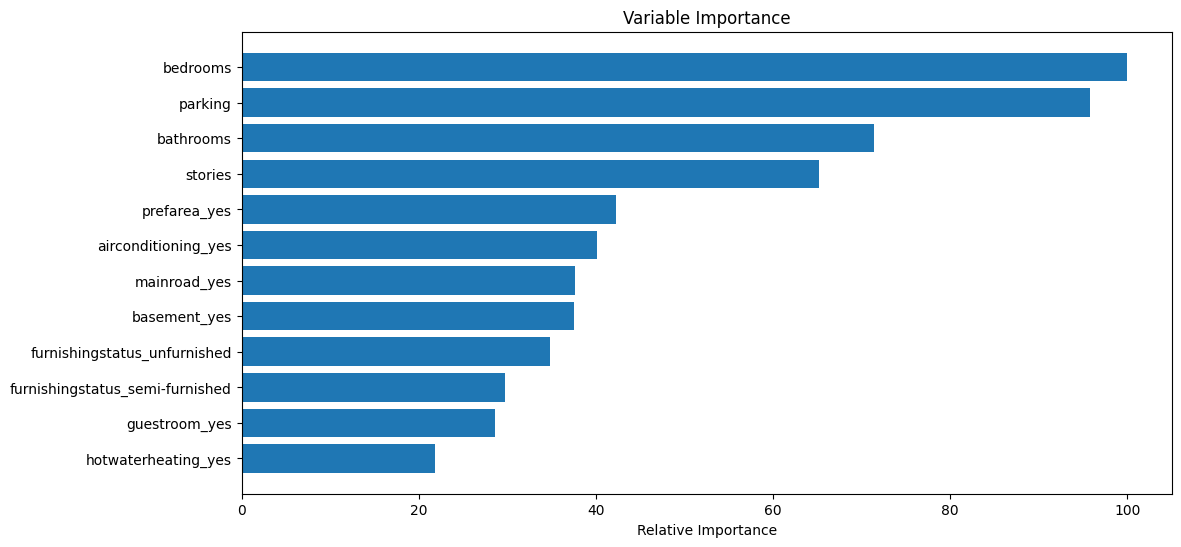

In [27]:
#determine feature importance
feature_importance = model.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
print(pos.size)
print(sorted_idx.size)
sorted_idx.size
feature_importance.size
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, X.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.show()



In [28]:
# Save the model and scalers to files
joblib.dump(model, 'house_price_model.pkl')
joblib.dump(feature_scaler, 'feature_scaler.pkl')
joblib.dump(target_scaler, 'target_scaler.pkl')
joblib.dump(X_train.columns, 'feature_columns.pkl')  # Save the feature columns

['feature_columns.pkl']

In [29]:
# Load the model and the scalers from the pkl files
model = joblib.load('house_price_model.pkl')
feature_scaler = joblib.load('feature_scaler.pkl')
target_scaler = joblib.load('target_scaler.pkl')
feature_columns = joblib.load('feature_columns.pkl')  # Load the feature columns

In [ ]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the model and the scalers from the pkl files
model = joblib.load('house_price_model.pkl')
feature_scaler = joblib.load('feature_scaler.pkl')
target_scaler = joblib.load('target_scaler.pkl')
feature_columns = joblib.load('feature_columns.pkl')  # Load the feature columns

# Function to get valid integer input within a specified range
def get_valid_int(prompt, min_value, max_value):
    while True:
        try:
            value = int(input(prompt))
            if min_value <= value <= max_value:
                return value
            else:
                print(f"Invalid input. Please enter a value between {min_value} and {max_value}.")
        except ValueError:
            print("Invalid input. Please enter a valid integer.")

# Function to get valid categorical input
def get_valid_categorical(prompt, valid_options):
    while True:
        value = input(prompt).strip().lower()
        if value in valid_options:
            return value
        else:
            print(f"Invalid input. Please enter one of the following options: {', '.join(valid_options)}")

# Function to get and validate all inputs
def get_and_validate_inputs():
    while True:
        try:
            bedrooms = get_valid_int('Enter the number of bedrooms : ', 0, 10)
            bathrooms = get_valid_int('Enter the number of bathrooms :', 0, 5)
            stories = get_valid_int('Enter the number of stories ', 0, 5)
            mainroad = get_valid_categorical('Is the house located on the main road? (yes/no): ', ['yes', 'no'])
            guestroom = get_valid_categorical('Does the house have a guest room? (yes/no): ', ['yes', 'no'])
            basement = get_valid_categorical('Does the house have a basement? (yes/no): ', ['yes', 'no'])
            hotwaterheating = get_valid_categorical('Does the house have hot water heating? (yes/no): ', ['yes', 'no'])
            airconditioning = get_valid_categorical('Does the house have air conditioning? (yes/no): ', ['yes', 'no'])
            parking = get_valid_int('Enter the number of parking spaces: ', 0, 5)
            prefarea = get_valid_categorical('Is the house in the preferred area? (yes/no): ', ['yes', 'no'])
            furnishingstatus = get_valid_categorical('Enter the furnishing status of the house (furnished, semi-furnished, unfurnished): ', ['furnished', 'semi-furnished', 'unfurnished'])
            if bedrooms == 0 and bathrooms == 0:
                print("Invalid input: Please try again")
                continue
            if bedrooms == 0 and bathrooms > 0:
                print("Invalid input: A house cannot have 0 bedrooms and more bathrooms.")
                continue
            if bedrooms == 0 or bathrooms == 0:
                print("Invalid input: A house must have at least one bedroom and one bathroom.")
                continue
            if bedrooms > 0 and bathrooms == 0:
                print("Invalid input: unrealistic measurements for a house.")
                continue
            if bedrooms == 0 and bathrooms == 0 and parking > 0:
                print("Invalid input: A house cannot have parking without any bedrooms or bathrooms.")
                continue
            if bathrooms >bedrooms:
                print("please try again not enough inputs")
                continue
            if basement == 'yes' and stories == 0:
                print("Invalid input: A house cannot have a basement without any stories.")
                continue
            if guestroom == 'yes' and bedrooms < 2:
                print("Invalid input: A house with a guest room must have at least two bedrooms.")
                continue
            if (bedrooms == 0 and bathrooms == 0 and stories == 0 and mainroad == 'no' and guestroom == 'no' and basement == 'no' and hotwaterheating == 'no' and airconditioning == 'no' and parking == 0 and prefarea == 'no' and furnishingstatus == 'unfurnished'):
                print('Invalid input: Nothing was inputed please try again')
                return None, None, None, None, None, None, None, None, None, None, None
            return bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus

        except KeyboardInterrupt:
            print("\nProcess interrupted by user. Exiting...")
            return None, None, None, None, None, None, None, None, None, None, None

# Function to predict house price
def predict_house_price():
    while True:
        bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus = get_and_validate_inputs()
        if bedrooms is None:
            break

        # Create a DataFrame for the input data
        input_data = pd.DataFrame({
            'bedrooms': [bedrooms],
            'bathrooms': [bathrooms],
            'stories': [stories],
            'parking': [parking],
            'mainroad_yes': [1 if mainroad == 'yes' else 0],
            'guestroom_yes': [1 if guestroom == 'yes' else 0],
            'basement_yes': [1 if basement == 'yes' else 0],
            'hotwaterheating_yes': [1 if hotwaterheating == 'yes' else 0],
            'airconditioning_yes': [1 if airconditioning == 'yes' else 0],
            'prefarea_yes': [1 if prefarea == 'yes' else 0],
            'furnishingstatus_semi-furnished': [1 if furnishingstatus == 'semi-furnished' else 0],
            'furnishingstatus_unfurnished': [1 if furnishingstatus == 'unfurnished' else 0]
        })

        # Ensure the input data has the same columns as the training data
        input_data = input_data.reindex(columns=feature_columns, fill_value=0)

        # Scale the input features
        x_scaled = feature_scaler.transform(input_data)

        # Predict the house price using the model
        scaled_price = model.predict(x_scaled)[0]

        # Unscale the predicted price
        unscaled_price = target_scaler.inverse_transform([[scaled_price]])[0][0]

        # Print the estimated price of the house unscaled
        print(f'The estimated price of the house is ${unscaled_price:.2f}')
        break

# Call the predict_house_price() function
predict_house_price()

please try again not enough inputs
